In [28]:
import pandas as pd
import numpy as np
import itertools
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pytorch_tabnet.tab_model import TabNetRegressor

path = r"C:\Users\Aaron\OneDrive\Desktop\Capstone\Data\Features"

precipitation = pd.read_csv(path + r"\Weather\Precipitation1985_2025.csv")
sunshineDuration = pd.read_csv(path + r"\Weather\SunshineDuration1985_2025.csv")
airTemperature = pd.read_csv(path + r"\Weather\AirTemperature1985_2025.csv")

In [29]:
season_map = {
    'September': 'Autumn', 'October': 'Autumn', 'November': 'Autumn',
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
}

roll_forward = ['September', 'October', 'November', 'December']

In [30]:
def season_weather(monthly_average, colname):
    df = monthly_average.copy()
    df['Season'] = df['Month'].map(season_map)

    rollOn_month = df['Month'].isin(roll_forward)
    df['HarvestYear'] = np.where(rollOn_month, df['Year'] + 1, df['Year'])

    season_avg = df.groupby(['HarvestYear', 'Season'])['Measurement'].mean().reset_index()

    pivot = season_avg.pivot(index='HarvestYear', columns='Season', values='Measurement')
    pivot.columns = [f'{colname}_{s}' for s in pivot.columns]

    return pivot.reset_index().rename(columns={'HarvestYear': 'Year'})


In [31]:
def build_features():
    return (season_weather(precipitation, 'Precip')
            .merge(season_weather(sunshineDuration, 'Sun'), on='Year')
            .merge(season_weather(airTemperature, 'TempMean'), on='Year'))


features = build_features()

In [32]:
def detrend_yield(yield_data):
    yield_copy = yield_data.copy()

    slope, intercept = np.polyfit(yield_copy['Year'], yield_copy['Tonnes'], deg=1)
    yield_copy['Trend'] = slope * yield_copy['Year'] + intercept
    yield_copy['Yield_Detrended'] = yield_copy['Tonnes'] - yield_copy['Trend']

    return yield_copy

In [33]:
loo = LeaveOneOut()

In [34]:
from sklearn.preprocessing import StandardScaler

def run_tabnet(X, y, params):
    X_values = X.values
    y_values = y.values.reshape(-1, 1)
 
    y_true = []
    y_pred = []
 
    for train_index, test_index in loo.split(X_values):
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_values[train_index])
        X_test_scaled = scaler.transform(X_values[test_index])
 
        model = TabNetRegressor(seed=42, verbose=0, **params)
        model.fit(X_train_scaled, y_values[train_index], max_epochs=100, batch_size=16, virtual_batch_size=8,)
 
        prediction = model.predict(X_test_scaled)[0][0]
        y_pred.append(prediction)
        y_true.append(y_values[test_index][0][0])
 
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
 
    return rmse, mae, r2

In [35]:
def best_hyperparameters_tabnet(X, y):
    
    hyperparameter_grid = {
        'n_d': [4, 8],
        'n_a': [4, 8],
        'n_steps': [2, 3],
        'gamma': [1.0, 1.3],
    }

    parameter_names = list(hyperparameter_grid.keys())
    parameter_value_lists = list(hyperparameter_grid.values())

    best_result = {'r2': -np.inf}

    for combination in itertools.product(*parameter_value_lists):
        params = dict(zip(parameter_names, combination))
        rmse, mae, r2 = run_tabnet(X, y, params)

        if r2 > best_result['r2']:
            best_result = {'params': params, 'rmse': rmse, 'mae': mae, 'r2': r2}

    print(f"Best TabNet hyperparameters: {best_result['params']} R2={best_result['r2']:.3f}")
    return best_result['params']


In [36]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='pytorch_tabnet')

In [37]:
crops_info = [
    (path + r"\CropYield\SpringWheat1985_2025.csv", 'SpringWheat'),
    (path + r"\CropYield\WinterWheat1985_2025.csv", 'WinterWheat'),
    (path + r"\CropYield\SpringBarley1985_2025.csv", 'SpringBarley'),
    (path + r"\CropYield\WinterBarley1985_2025.csv", 'WinterBarley'),
    (path + r"\CropYield\SpringOats1985_2025.csv", 'SpringOats'),
    (path + r"\CropYield\WinterOats1985_2025.csv", 'WinterOats'),
    (path + r"\CropYield\Potatoes1985_2025.csv", 'Potatoes'),
    (path + r"\CropYield\OilseedRape1985_2025.csv", 'OilseedRape'),
    (path + r"\CropYield\BeansAndPeas1985_2025.csv", 'BeansAndPeas'),
]

reference_yield = detrend_yield(pd.read_csv(crops_info[0][0])[['Year', 'Tonnes']])
reference_data = features.merge(reference_yield, on='Year').dropna().sort_values('Year').reset_index(drop=True)

X_reference = reference_data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
y_reference = reference_data['Yield_Detrended']

params_tabnet = best_hyperparameters_tabnet(X_reference, y_reference)

Best TabNet hyperparameters: {'n_d': 4, 'n_a': 8, 'n_steps': 3, 'gamma': 1.0} R2=0.214


In [38]:
for csv_path, crop_name in crops_info:

    yield_df = detrend_yield(pd.read_csv(csv_path)[['Year', 'Tonnes']])
    data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)

    X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
    y = data['Yield_Detrended']

    rmse, mae, r2 = run_tabnet(X, y, params_tabnet)
    print(f"{crop_name:15s} RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}")

SpringWheat     RMSE=0.592  MAE=0.460  R2=0.214
WinterWheat     RMSE=1.119  MAE=0.918  R2=-0.614
SpringBarley    RMSE=0.660  MAE=0.560  R2=-0.286
WinterBarley    RMSE=1.080  MAE=0.673  R2=-1.602
SpringOats      RMSE=0.530  MAE=0.424  R2=-0.152
WinterOats      RMSE=0.452  MAE=0.355  R2=0.033
Potatoes        RMSE=3.947  MAE=2.907  R2=-0.102
OilseedRape     RMSE=0.976  MAE=0.740  R2=-0.558
BeansAndPeas    RMSE=1.746  MAE=1.280  R2=-0.817


In [ ]:
def permutation_test_tabnet(X, y, params, shuffles=100, seed=1):
    rng = np.random.default_rng(seed)

    _, _, r2 = run_tabnet(X, y, params)

    permuted_r2 = []

    for i in range(shuffles):
        shuffled_y = pd.Series(rng.permutation(y.values), index=y.index)
        _, _, perm_r2 = run_tabnet(X, shuffled_y, params)
        permuted_r2.append(perm_r2)

        if (i + 1) % 20 == 0:
            print(f"{i + 1}/{shuffles} shuffles done")

    permuted_r2 = np.array(permuted_r2)
    good_permutations = np.sum(permuted_r2 >= r2)
    p_value = (good_permutations + 1) / (shuffles + 1)

    return r2, p_value

In [ ]:
spring_wheat = path + r"\CropYield\SpringWheat1985_2025.csv"
 
yield_df = detrend_yield(pd.read_csv(spring_wheat)[['Year', 'Tonnes']])
data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)
 
X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
y = data['Yield_Detrended']
 
print("Spring Wheat")
 
r2, p_value = permutation_test_tabnet(X, y, params_tabnet, shuffles=100)
 
print(f"R2={r2:.3f}")
print(f"p={p_value:.4f}")

### Pooling Experement

In [ ]:
cereal_crops_info = [
    (path + r"\CropYield\SpringWheat1985_2025.csv", 'SpringWheat'),
    (path + r"\CropYield\WinterWheat1985_2025.csv", 'WinterWheat'),
    (path + r"\CropYield\SpringBarley1985_2025.csv", 'SpringBarley'),
    (path + r"\CropYield\WinterBarley1985_2025.csv", 'WinterBarley'),
    (path + r"\CropYield\SpringOats1985_2025.csv", 'SpringOats'),
    (path + r"\CropYield\WinterOats1985_2025.csv", 'WinterOats'),
]
 
all_crop_rows = []

for csv_path, crop_name in cereal_crops_info:
    yield_df = detrend_yield(pd.read_csv(csv_path)[['Year', 'Tonnes']])
    data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)
    data['Crop'] = crop_name
    all_crop_rows.append(data)
 
pooled_data = pd.concat(all_crop_rows, ignore_index=True)
pooled_data = pd.get_dummies(pooled_data, columns=['Crop'])
 
X_pooled = pooled_data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
y_pooled = pooled_data['Yield_Detrended']

crop_labels_array = pooled_data.filter(like='Crop_').idxmax(axis=1).values
 
print(f"\nPooled dataset: n={len(pooled_data)} Features={X_pooled.shape[1]}")
 
pooled_params = dict(n_d=4, n_a=8, n_steps=3, gamma=1.0)  


Pooled dataset: n=240 Features=18


### Row level LOOCV, Data leaking

In [47]:
X_values = X_pooled.values.astype(np.float32)
y_values = y_pooled.values.reshape(-1, 1)
 
y_true, y_pred = [], []

for train_index, test_index in loo.split(X_values):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_values[train_index])
    X_test_scaled = scaler.transform(X_values[test_index])
 
    model = TabNetRegressor(seed=42, verbose=0, **pooled_params)
    model.fit(X_train_scaled, y_values[train_index], max_epochs=100, batch_size=16, virtual_batch_size=8)
 
    y_pred.append(model.predict(X_test_scaled)[0][0])
    y_true.append(y_values[test_index][0][0])
 
y_true, y_pred = np.array(y_true), np.array(y_pred)
r2 = r2_score(y_true, y_pred)

print(f"\nPooled TabNet : R2={r2:.3f}")
 
results_by_crop = pd.DataFrame({'crop': crop_labels_array, 'y_true': y_true, 'y_pred': y_pred})

for crop_name, group in results_by_crop.groupby('crop'):
    print(f"{crop_name:20s} R2={r2_score(group['y_true'], group['y_pred']):.3f}")


Pooled TabNet : R2=0.360
  Crop_SpringBarley    R2=0.475
  Crop_SpringOats      R2=0.195
  Crop_SpringWheat     R2=0.441
  Crop_WinterBarley    R2=0.406
  Crop_WinterOats      R2=0.379
  Crop_WinterWheat     R2=0.284


### LOOCV No Leaks, Splitting by Year

In [48]:
years_present = sorted(pooled_data['Year'].unique())
 
y_true, y_pred, crop_of_prediction = [], [], []

for held_out_year in years_present:
    test_mask = (pooled_data['Year'].values == held_out_year)
    train_mask = ~test_mask
 
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_values[train_mask])
    X_test_scaled = scaler.transform(X_values[test_mask])
 
    model = TabNetRegressor(seed=42, verbose=0, **pooled_params)
    model.fit(X_train_scaled, y_pooled.values[train_mask].reshape(-1, 1),max_epochs=100, batch_size=16, virtual_batch_size=8)
 
    y_pred.extend(model.predict(X_test_scaled).flatten())
    y_true.extend(y_pooled.values[test_mask])
    crop_of_prediction.extend(crop_labels_array[test_mask])
 
y_true, y_pred = np.array(y_true), np.array(y_pred)
r2 = r2_score(y_true, y_pred)
print(f"\nPooled TabNet: R2={r2:.3f}")
 
results_by_crop = pd.DataFrame({'crop': crop_of_prediction, 'y_true': y_true, 'y_pred': y_pred})

print("R2 Score:")

for crop_name, group in results_by_crop.groupby('crop'):
    print(f"{crop_name:20s} R2={r2_score(group['y_true'], group['y_pred']):.3f}")


Pooled TabNet: R2=0.040
R2 Score:
Crop_SpringBarley    R2=-0.037
Crop_SpringOats      R2=-0.025
Crop_SpringWheat     R2=0.071
Crop_WinterBarley    R2=0.116
Crop_WinterOats      R2=-0.050
Crop_WinterWheat     R2=0.055



SpringWheat Feature importance:
  Sun_Autumn           0.1842
  TempMean_Spring      0.1683
  Precip_Summer        0.1213
  Sun_Summer           0.1120
  Precip_Spring        0.0993
  TempMean_Summer      0.0796
  Precip_Winter        0.0690
  Sun_Spring           0.0566
  Sun_Winter           0.0421
  TempMean_Winter      0.0299
  TempMean_Autumn      0.0275
  Precip_Autumn        0.0104


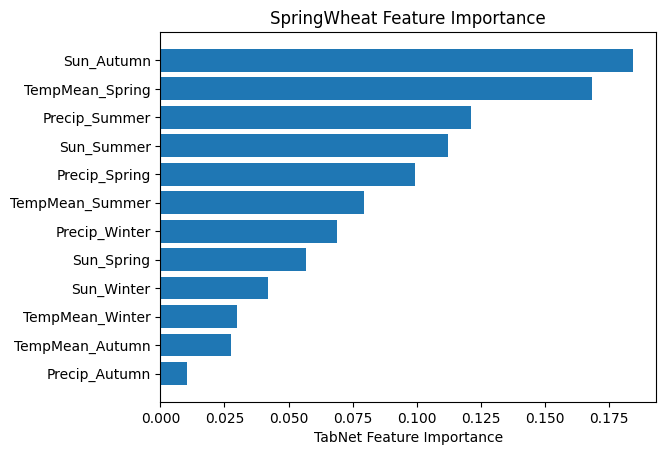


SpringBarley Feature importance:
  Sun_Autumn           0.2771
  Precip_Spring        0.2630
  Sun_Summer           0.1556
  Sun_Spring           0.1077
  TempMean_Winter      0.0540
  TempMean_Autumn      0.0456
  TempMean_Spring      0.0402
  Sun_Winter           0.0393
  Precip_Autumn        0.0139
  TempMean_Summer      0.0036
  Precip_Summer        0.0001
  Precip_Winter        0.0000


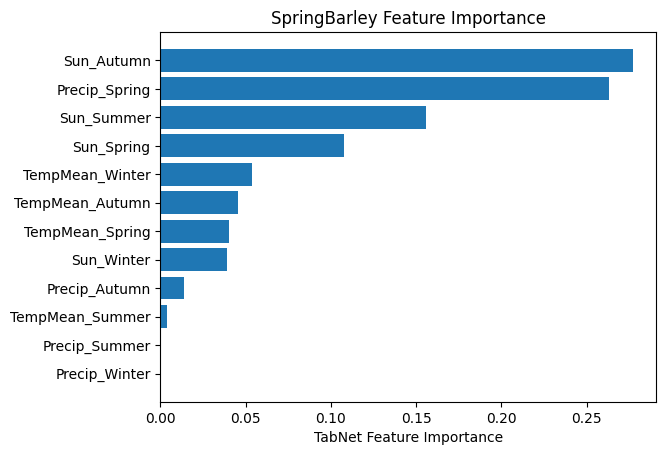


SpringOats Feature importance:
  TempMean_Winter      0.1828
  Sun_Summer           0.1658
  Precip_Summer        0.1580
  TempMean_Autumn      0.1148
  Sun_Spring           0.0911
  Precip_Spring        0.0808
  Sun_Autumn           0.0781
  TempMean_Summer      0.0380
  Precip_Autumn        0.0339
  Precip_Winter        0.0307
  Sun_Winter           0.0228
  TempMean_Spring      0.0032


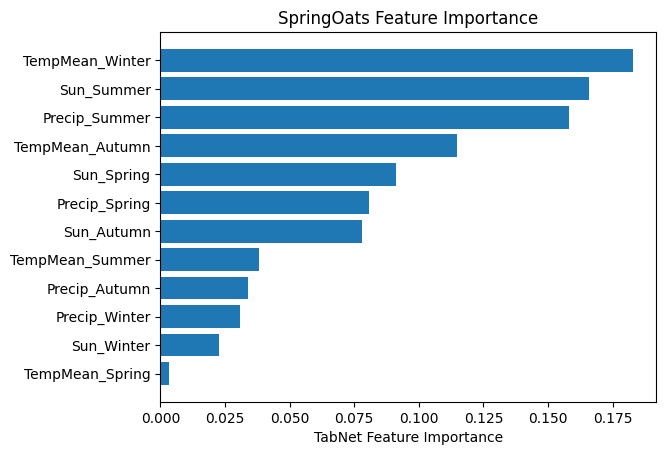


Potatoes Feature importance:
  Precip_Summer        0.2122
  TempMean_Autumn      0.1479
  Precip_Spring        0.1177
  Sun_Winter           0.1012
  TempMean_Summer      0.0989
  Precip_Winter        0.0966
  Sun_Summer           0.0616
  TempMean_Spring      0.0579
  TempMean_Winter      0.0504
  Sun_Autumn           0.0393
  Precip_Autumn        0.0086
  Sun_Spring           0.0076


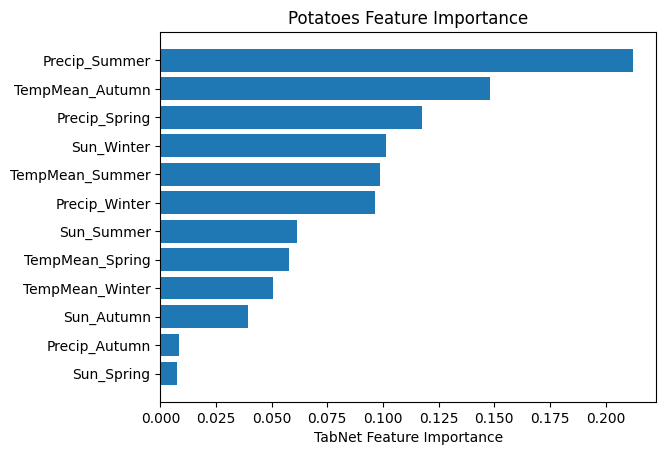

In [49]:
import matplotlib.pyplot as plt

significant_crops = [
    (path + r"\CropYield\SpringWheat1985_2025.csv", 'SpringWheat'),
    (path + r"\CropYield\SpringBarley1985_2025.csv", 'SpringBarley'),
    (path + r"\CropYield\SpringOats1985_2025.csv", 'SpringOats'),
    (path + r"\CropYield\Potatoes1985_2025.csv", 'Potatoes'),
]
 
for csv_path, crop_name in significant_crops:
    yield_df = detrend_yield(pd.read_csv(csv_path)[['Year', 'Tonnes']])
    data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)
 
    X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
    y = data['Yield_Detrended']
 
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.values)
    y_values = y.values.reshape(-1, 1)
 
    model = TabNetRegressor(seed=42, verbose=0, **pooled_params)
    model.fit(X_scaled, y_values, max_epochs=100, batch_size=16, virtual_batch_size=8)
 
    importances = model.feature_importances_
    sorted_pairs = sorted(zip(X.columns.tolist(), importances), key=lambda pair: pair[1], reverse=True)
    sorted_names = [pair[0] for pair in sorted_pairs]
    sorted_scores = [pair[1] for pair in sorted_pairs]
 
    print(f"\n{crop_name} Feature importance:")
    for name, score in zip(sorted_names, sorted_scores):
        print(f"  {name:20s} {score:.4f}")
 
    plt.barh(sorted_names[::-1], sorted_scores[::-1])
    plt.xlabel('TabNet Feature Importance')
    plt.title(f'{crop_name} Feature Importance')
    plt.show()

### Individual Hyperparameter Tuning

In [50]:
per_crop_results = []
 
for csv_path, crop_name in crops_info:
    yield_df = detrend_yield(pd.read_csv(csv_path)[['Year', 'Tonnes']])
    data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)
 
    X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
    y = data['Yield_Detrended']
 
    print(f"\n{crop_name}")
    best_params = best_hyperparameters_tabnet(X, y)
 
    rmse, mae, r2 = run_tabnet(X, y, best_params)
    print(f"{crop_name:15s} RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}  params={best_params}")
 
    per_crop_results.append({
        'crop': crop_name, 'rmse': rmse, 'mae': mae, 'r2': r2, 'params': best_params,
    })
 
per_crop_table = pd.DataFrame(per_crop_results)

print("\n\nPer-crop tuned results")
print(per_crop_table[['crop', 'r2', 'params']])


SpringWheat
Best TabNet hyperparameters: {'n_d': 4, 'n_a': 8, 'n_steps': 3, 'gamma': 1.0} R2=0.214
SpringWheat     RMSE=0.592  MAE=0.460  R2=0.214  params={'n_d': 4, 'n_a': 8, 'n_steps': 3, 'gamma': 1.0}

WinterWheat
Best TabNet hyperparameters: {'n_d': 4, 'n_a': 8, 'n_steps': 2, 'gamma': 1.3} R2=0.061
WinterWheat     RMSE=0.853  MAE=0.657  R2=0.061  params={'n_d': 4, 'n_a': 8, 'n_steps': 2, 'gamma': 1.3}

SpringBarley
Best TabNet hyperparameters: {'n_d': 4, 'n_a': 4, 'n_steps': 3, 'gamma': 1.3} R2=-0.017
SpringBarley    RMSE=0.587  MAE=0.464  R2=-0.017  params={'n_d': 4, 'n_a': 4, 'n_steps': 3, 'gamma': 1.3}

WinterBarley
Best TabNet hyperparameters: {'n_d': 4, 'n_a': 8, 'n_steps': 3, 'gamma': 1.3} R2=0.155
WinterBarley    RMSE=0.615  MAE=0.509  R2=0.155  params={'n_d': 4, 'n_a': 8, 'n_steps': 3, 'gamma': 1.3}

SpringOats
Best TabNet hyperparameters: {'n_d': 4, 'n_a': 4, 'n_steps': 3, 'gamma': 1.0} R2=0.079
SpringOats      RMSE=0.474  MAE=0.364  R2=0.079  params={'n_d': 4, 'n_a': 4, 

In [51]:
tabnet_winter_crops = [
    (path + r"\CropYield\WinterWheat1985_2025.csv", 'WinterWheat', {'n_d': 4, 'n_a': 8, 'n_steps': 2, 'gamma': 1.3}),
    (path + r"\CropYield\WinterBarley1985_2025.csv", 'WinterBarley', {'n_d': 4, 'n_a': 8, 'n_steps': 3, 'gamma': 1.3}),
]

for csv_path, crop_name, crop_params in tabnet_winter_crops:
    yield_df = detrend_yield(pd.read_csv(csv_path)[['Year', 'Tonnes']])
    data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)

    X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
    y = data['Yield_Detrended']

    print(f"\n{crop_name}")
    r2, p_value = permutation_test_tabnet(X, y, crop_params, shuffles=100)
    
    print(f"R2={r2:.3f}")
    print(f"p={p_value:.4f}")


WinterWheat
    ...20/100 shuffles done
    ...40/100 shuffles done
    ...60/100 shuffles done
    ...80/100 shuffles done
    ...100/100 shuffles done
R2=0.061
p=0.0198

WinterBarley
    ...20/100 shuffles done
    ...40/100 shuffles done
    ...60/100 shuffles done
    ...80/100 shuffles done
    ...100/100 shuffles done
R2=0.155
p=0.0099


In [ ]:
winter_barley = path + r"\CropYield\WinterBarley1985_2025.csv"
param = {'n_d': 4, 'n_a': 8, 'n_steps': 3, 'gamma': 1.3}
 
yield_df = detrend_yield(pd.read_csv(winter_barley)[['Year', 'Tonnes']])
data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)
 
X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
y = data['Yield_Detrended']
 
print("Winter Barley")

r2, p_value = permutation_test_tabnet(X, y, param, shuffles=500)

print(f"R2={r2:.3f}")
print(f"p={p_value:.4f}")

Winter Barley
    ...20/500 shuffles done
    ...40/500 shuffles done
    ...60/500 shuffles done
    ...80/500 shuffles done
    ...100/500 shuffles done
    ...120/500 shuffles done
    ...140/500 shuffles done
    ...160/500 shuffles done
    ...180/500 shuffles done
    ...200/500 shuffles done
    ...220/500 shuffles done
    ...240/500 shuffles done
    ...260/500 shuffles done
